### Data Synthesis for Simple Harmonic Oscilator

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# SHO parameters
A = 32         # amplitude
omega = 6.0       # angular frequency (rad/s)
phi = 0.0         # phase offset
noise_std = 0.05*A  # std dev of Gaussian noise

# Time vector
t_start, t_end, n_points = 0, 10, 500
t = np.linspace(t_start, t_end, n_points)

In [2]:
# Clean displacement: x(t) = A cos(omega t + phi)
x_clean = A * np.cos(omega * t + phi)

# Add Gaussian noise
rng = np.random.default_rng(seed=42)
noise = rng.normal(loc=0.0, scale=noise_std, size=t.shape)
x_noisy = x_clean + noise

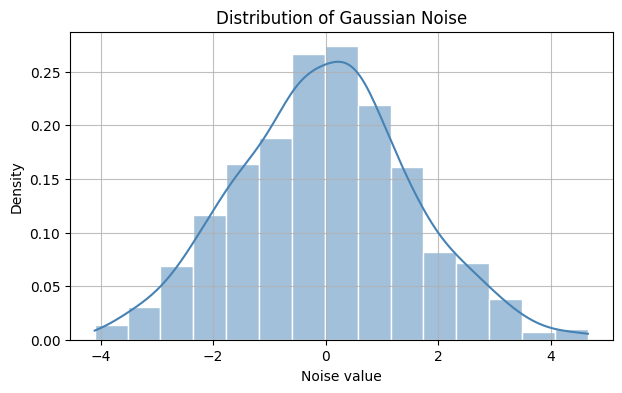

In [3]:
import seaborn as sns
plt.figure(figsize=(7, 4))
sns.histplot(noise, kde=True, stat="density", bins=15, color="steelblue", edgecolor="white")
plt.xlabel("Noise value")
plt.ylabel("Density")
plt.title("Distribution of Gaussian Noise")
plt.grid(alpha=0.8)
plt.show()

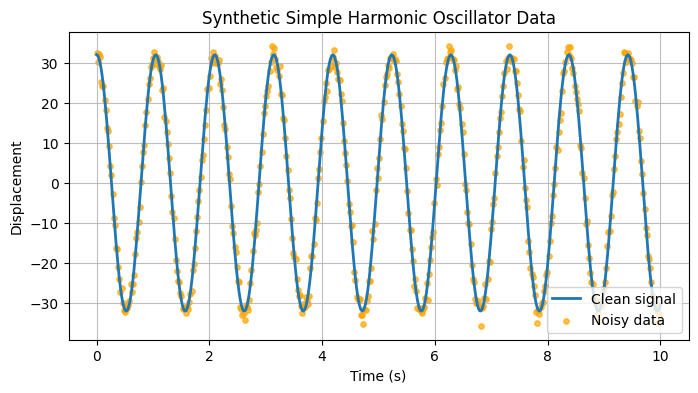

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, x_clean, label="Clean signal", linewidth=2)
ax.scatter(t, x_noisy, color="orange", s=15, label="Noisy data", alpha=0.7)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("Synthetic Simple Harmonic Oscillator Data")
ax.legend(loc="lower right")
ax.grid(alpha=0.8)

### Simple ANN approach to attempt modelling the SHO

In [5]:
import torch
import torch.nn as nn

# Convert data to tensors (reshape to column vectors)
t_tensor = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
x_tensor = torch.tensor(x_noisy, dtype=torch.float32).reshape(-1, 1)

# Normalize inputs
t_mean, t_std = t_tensor.mean(), t_tensor.std()
#t_mean, t_std = torch.tensor(0.0), torch.tensor(1.0) # Un-normalization
t_norm = (t_tensor - t_mean) / t_std

# Normalize targets
x_mean, x_std = x_tensor.mean(), x_tensor.std()
#x_mean, x_std = torch.tensor(0.0), torch.tensor(1.0) # Un-normalization
x_norm = (x_tensor - x_mean) / x_std

In [6]:
class SHONet(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SHONet()

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

n_epochs = 2000
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred = model(t_norm)
    loss = criterion(pred, x_norm)   # compare in normalized space
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}")

Epoch 200/2000, Loss: 0.994439
Epoch 400/2000, Loss: 0.869231
Epoch 600/2000, Loss: 0.591539
Epoch 800/2000, Loss: 0.372178
Epoch 1000/2000, Loss: 0.149223
Epoch 1200/2000, Loss: 0.009485
Epoch 1400/2000, Loss: 0.005604
Epoch 1600/2000, Loss: 0.004672
Epoch 1800/2000, Loss: 0.004646
Epoch 2000/2000, Loss: 0.004246


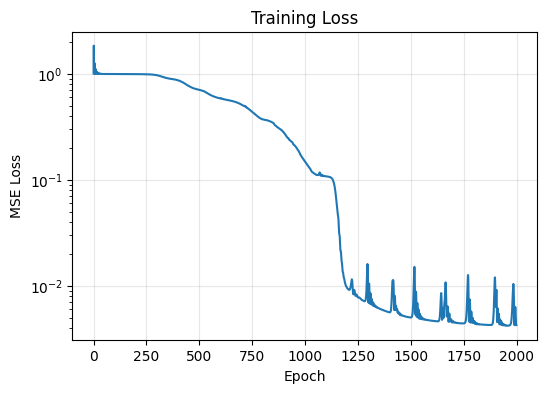

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.show()

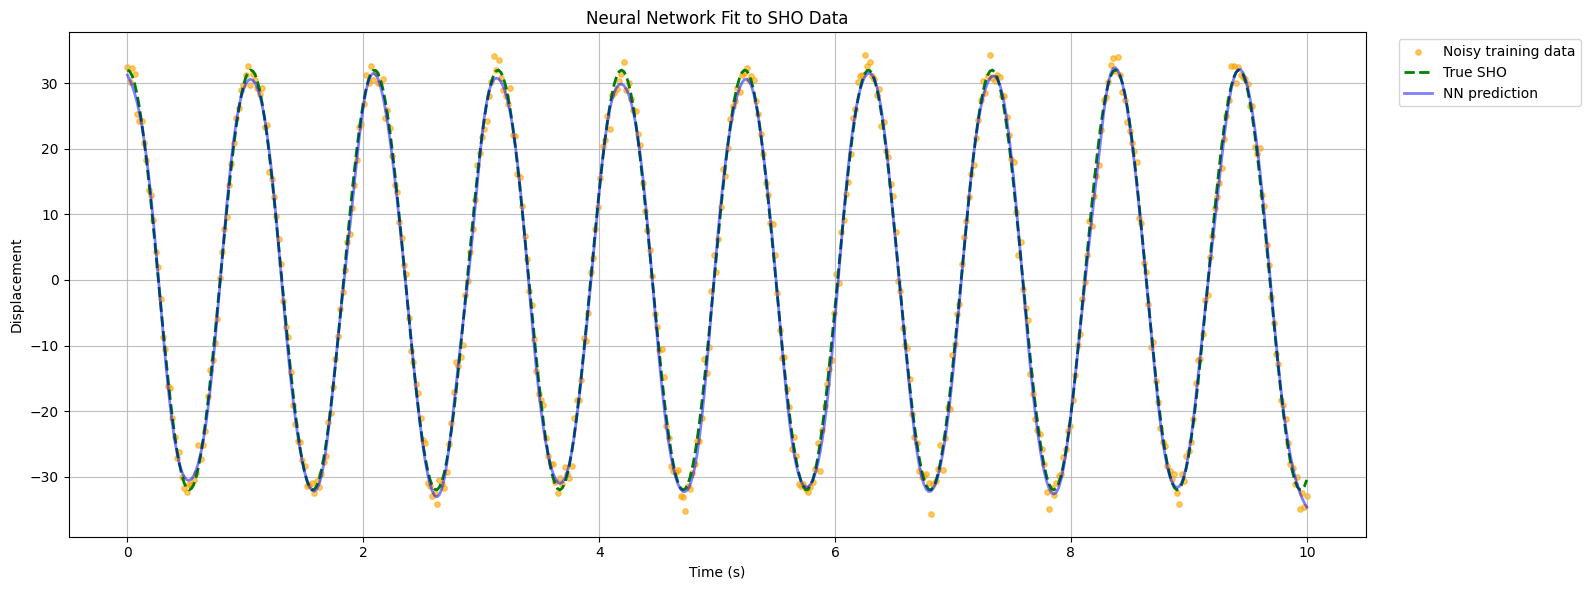

In [9]:
model.eval()
with torch.no_grad():
    t_fine = np.linspace(t_start, t_end, 500)
    t_fine_tensor = torch.tensor(t_fine, dtype=torch.float32).reshape(-1, 1)
    t_fine_norm = (t_fine_tensor - t_mean) / t_std

    x_pred_norm = model(t_fine_norm)
    x_pred = (x_pred_norm * x_std + x_mean).numpy().flatten()  # <-- unnormalize

x_true_fine = A * np.cos(omega * t_fine + phi)

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(t, x_noisy, s=15, color="orange", alpha=0.6, label="Noisy training data")
ax.plot(t_fine, x_true_fine, color="green", linewidth=2, alpha = 1, label="True SHO", linestyle="--")
ax.plot(t_fine, x_pred, color="blue", linewidth=2, alpha = 0.5, label="NN prediction")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("Neural Network Fit to SHO Data")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.grid(alpha=0.8)
plt.show()

**Observations**:

When data is not normalized:
- The larger the amplitude, a good fit requires a larger quantity of epochs. 
- Something similar is observed as frequency increse.
- Small number of epochs leads to underfitting

Normalization seems to solve this problem

### Test validation

Out of training sample - forecasting

In [10]:
# Training was on t in [0, 10]; test on new times beyond that range
t_out_start, t_out_end, n_out_points = 10, 15, 100
t_out = np.linspace(t_out_start, t_out_end, n_out_points)

t_out_tensor = torch.tensor(t_out, dtype=torch.float32).reshape(-1, 1)
t_out_norm = (t_out_tensor - t_mean) / t_std   # normalize using TRAINING mean/std

# Ground truth for comparison (since we know the analytic form)
x_out_true = A * np.cos(omega * t_out + phi)

Sample inside training range - interolation

In [11]:
rng_test = np.random.default_rng(seed=123)  # different seed than training noise
t_out = np.sort(rng_test.uniform(t_start, t_end, n_out_points))

t_out_tensor = torch.tensor(t_out, dtype=torch.float32).reshape(-1, 1)
t_out_norm = (t_out_tensor - t_mean) / t_std

x_out_true = A * np.cos(omega * t_out + phi)

In [12]:
model.eval()
with torch.no_grad():
    x_out_pred_norm = model(t_out_norm)
    x_out_pred = (x_out_pred_norm * x_std + x_mean).numpy().flatten()

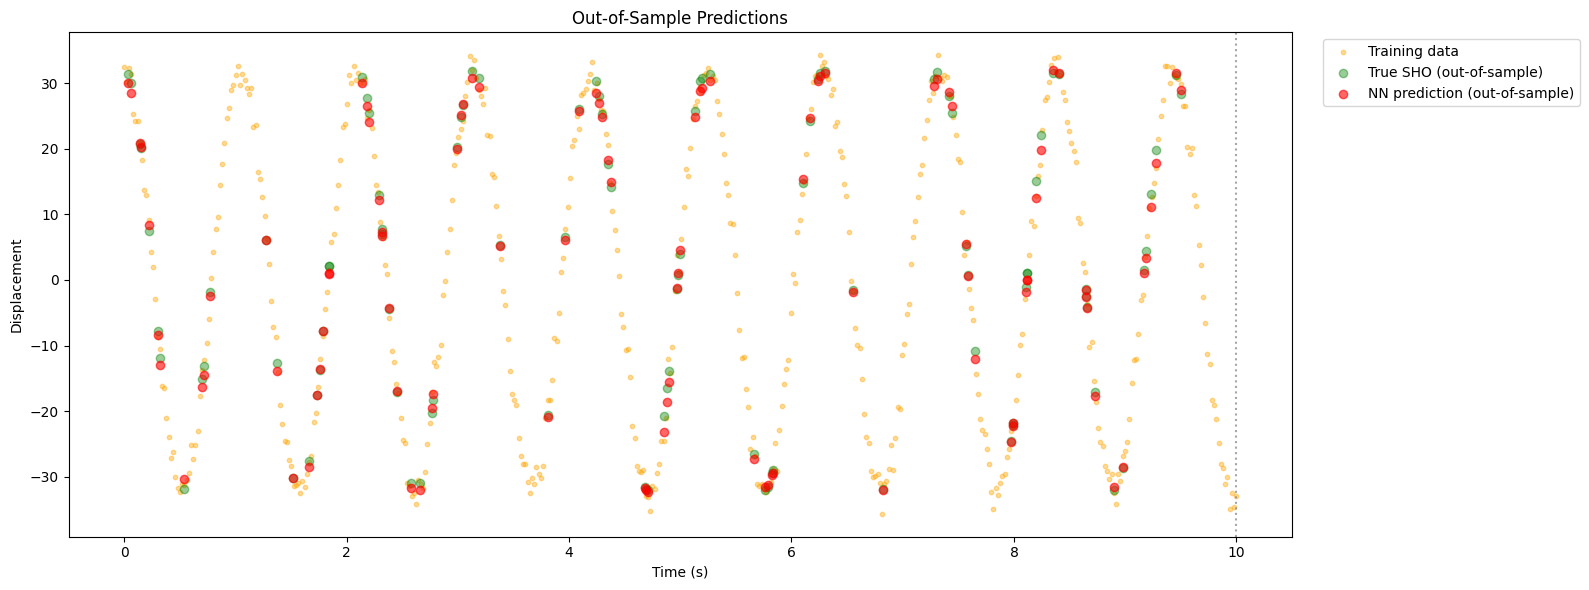

In [13]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(t, x_noisy, s=10, color="orange", alpha=0.4, label="Training data")
ax.scatter(t_out, x_out_true, color="green", alpha=0.4, label="True SHO (out-of-sample)")
ax.scatter(t_out, x_out_pred, color="red", alpha=0.6, label="NN prediction (out-of-sample)")
ax.axvline(t_end, color="gray", linestyle=":", alpha=0.7)  # marks end of training range
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("Out-of-Sample Predictions")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

**Insights**
- For values inside the training range predictions look good
- Model seems to overfit, because it's bad at predicting values outside the training range

### Physics Informed Neural Network

In [33]:
import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, t):
        return self.net(t)

model = PINN()

In [34]:
# Data points: your existing noisy measurements
t_data = torch.tensor(t, dtype=torch.float32).reshape(-1, 1)
x_data = torch.tensor(x_noisy, dtype=torch.float32).reshape(-1, 1)

t_mean, t_std = t_data.mean(), t_data.std()
x_mean, x_std = x_data.mean(), x_data.std()

t_data_norm = (t_data - t_mean) / t_std
x_data_norm = (x_data - x_mean) / x_std

# Collocation points: dense grid where we enforce the physics
# These can extend BEYOND the data range -- this is what lets PINNs extrapolate
t_colloc = torch.linspace(t_start, t_end + 5, 1000).reshape(-1, 1)
t_colloc_norm = ((t_colloc - t_mean) / t_std).requires_grad_(True)  # need grad for autodiff

In [ ]:
def physics_residual(model, t_norm, omega, t_std, x_std):
    """
    Computes x'' + omega^2 * x = 0
    correcting for the chain rule introduced by normalization.
    """
    x_norm = model(t_norm)

    # dx_norm/dt_norm via autograd
    dx_norm = torch.autograd.grad(x_norm, t_norm, grad_outputs=torch.ones_like(x_norm),
                                   create_graph=True)[0]
    d2x_norm = torch.autograd.grad(dx_norm, t_norm, grad_outputs=torch.ones_like(dx_norm),
                                    create_graph=True)[0]

    # Chain rule: since t_norm = (t - t_mean)/t_std and x_norm = (x - x_mean)/x_std,
    # d2x/dt2 = (x_std / t_std^2) * d2x_norm/dt_norm2
    d2x_dt2 = (x_std / t_std**2) * d2x_norm
    x_real = x_norm * x_std + x_mean

    residual = d2x_dt2 + (omega**2) * x_real
    return residual

def ic_loss(model, t_mean, t_std, x_mean, x_std, x0, v0):
    """
    Enforces x(0) = x0 and x'(0) = v0
    """
    t0 = torch.tensor([[0.0]], requires_grad=True)
    t0_norm = (t0 - t_mean) / t_std

    x0_pred_norm = model(t0_norm)
    x0_pred_real = x0_pred_norm * x_std + x_mean

    dx0_norm = torch.autograd.grad(x0_pred_norm, t0_norm,
                                    grad_outputs=torch.ones_like(x0_pred_norm),
                                    create_graph=True)[0]
    # chain rule: dx/dt = (x_std/t_std) * dx_norm/dt_norm
    v0_pred_real = (x_std / t_std) * dx0_norm

    loss_x0 = (x0_pred_real - x0)**2
    loss_v0 = (v0_pred_real - v0)**2

    return loss_x0.squeeze() + loss_v0.squeeze()

In [36]:
x0_true = A * np.cos(phi)          # x(0) = A cos(phi)
v0_true = -A * omega * np.sin(phi)  # x'(0) = -A*omega*sin(phi)

x0_true_t = torch.tensor(x0_true, dtype=torch.float32)
v0_true_t = torch.tensor(v0_true, dtype=torch.float32)

In [39]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

n_epochs = int(5e4)
lambda_physics = 1e-6  # weight for physics loss relative to data loss
lambda_ic = 10e-6

losses_data, losses_physics, losses_ic, losses_total = [], [], [], []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Data loss
    x_pred_norm = model(t_data_norm)
    loss_data = criterion(x_pred_norm, x_data_norm)

    # Physics loss (ODE residual)
    residual = physics_residual(model, t_colloc_norm, omega, t_std, x_std)
    loss_physics = torch.mean(residual**2)

    # Initial condition loss
    loss_ic = ic_loss(model, t_mean, t_std, x_mean, x_std, x0_true_t, v0_true_t)

    loss = loss_data + lambda_physics * loss_physics + lambda_ic * loss_ic
    loss.backward()
    optimizer.step()

    losses_data.append(loss_data.item())
    losses_physics.append(loss_physics.item())
    losses_ic.append(loss_ic.item())
    losses_total.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | Total: {loss.item():.5f} | "
              f"Data: {loss_data.item():.5f} | Physics: {loss_physics.item():.5f} | "
              f"IC: {loss_ic.item():.5f}")

Epoch 500/50000 | Total: 1.00685 | Data: 0.99743 | Physics: 346.76447 | IC: 906.97833
Epoch 1000/50000 | Total: 1.00557 | Data: 0.99669 | Physics: 516.44891 | IC: 835.73492
Epoch 1500/50000 | Total: 1.00412 | Data: 0.99527 | Physics: 848.86444 | IC: 799.68591
Epoch 2000/50000 | Total: 1.00331 | Data: 0.99418 | Physics: 866.09955 | IC: 826.55499
Epoch 2500/50000 | Total: 1.00271 | Data: 0.99303 | Physics: 876.22180 | IC: 880.30682
Epoch 3000/50000 | Total: 1.00223 | Data: 0.99183 | Physics: 895.27521 | IC: 950.37537
Epoch 3500/50000 | Total: 1.00171 | Data: 0.99052 | Physics: 897.44757 | IC: 1029.79443
Epoch 4000/50000 | Total: 1.00075 | Data: 0.98869 | Physics: 905.66907 | IC: 1115.27405
Epoch 4500/50000 | Total: 0.99801 | Data: 0.98504 | Physics: 873.44049 | IC: 1210.09204
Epoch 5000/50000 | Total: 0.98596 | Data: 0.97127 | Physics: 904.14087 | IC: 1378.15771
Epoch 5500/50000 | Total: 0.94727 | Data: 0.93010 | Physics: 1315.01025 | IC: 1586.18262
Epoch 6000/50000 | Total: 0.88033 | Da

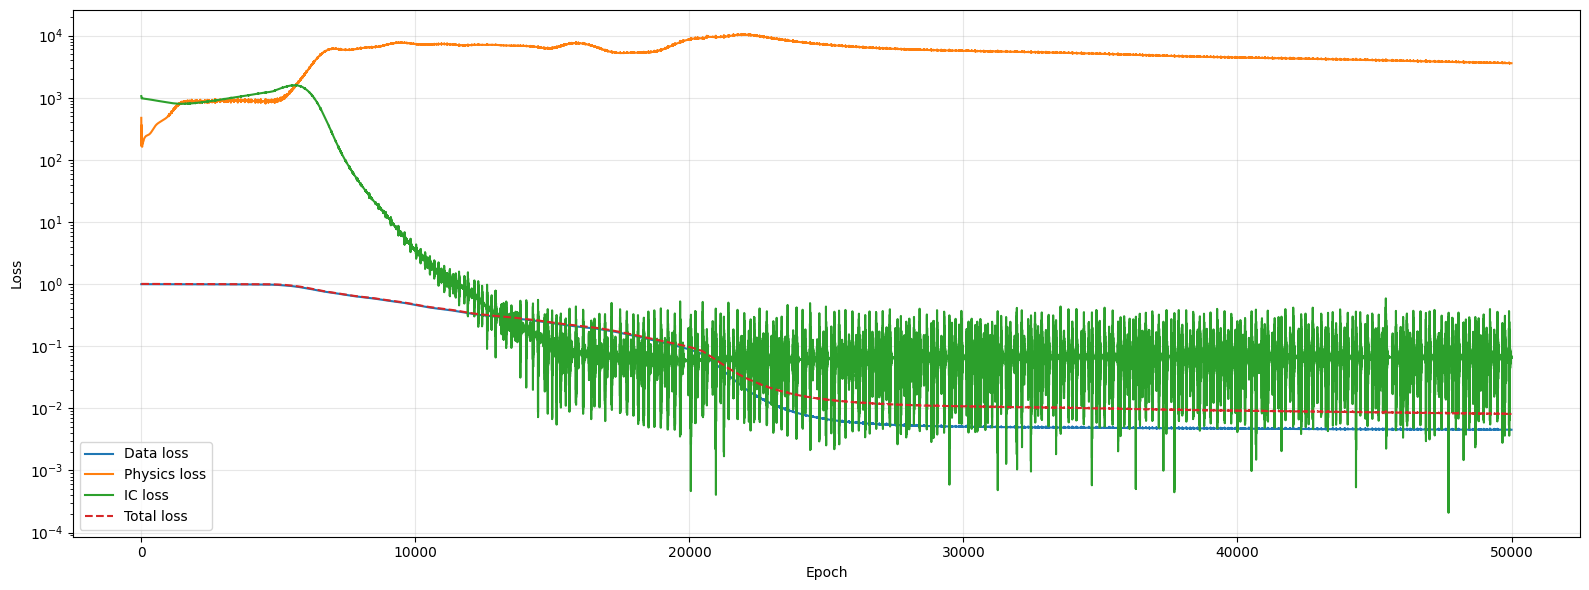

In [42]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(losses_data, label="Data loss")
ax.plot(losses_physics, label="Physics loss")
ax.plot(losses_ic, label="IC loss")
ax.plot(losses_total, label="Total loss", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

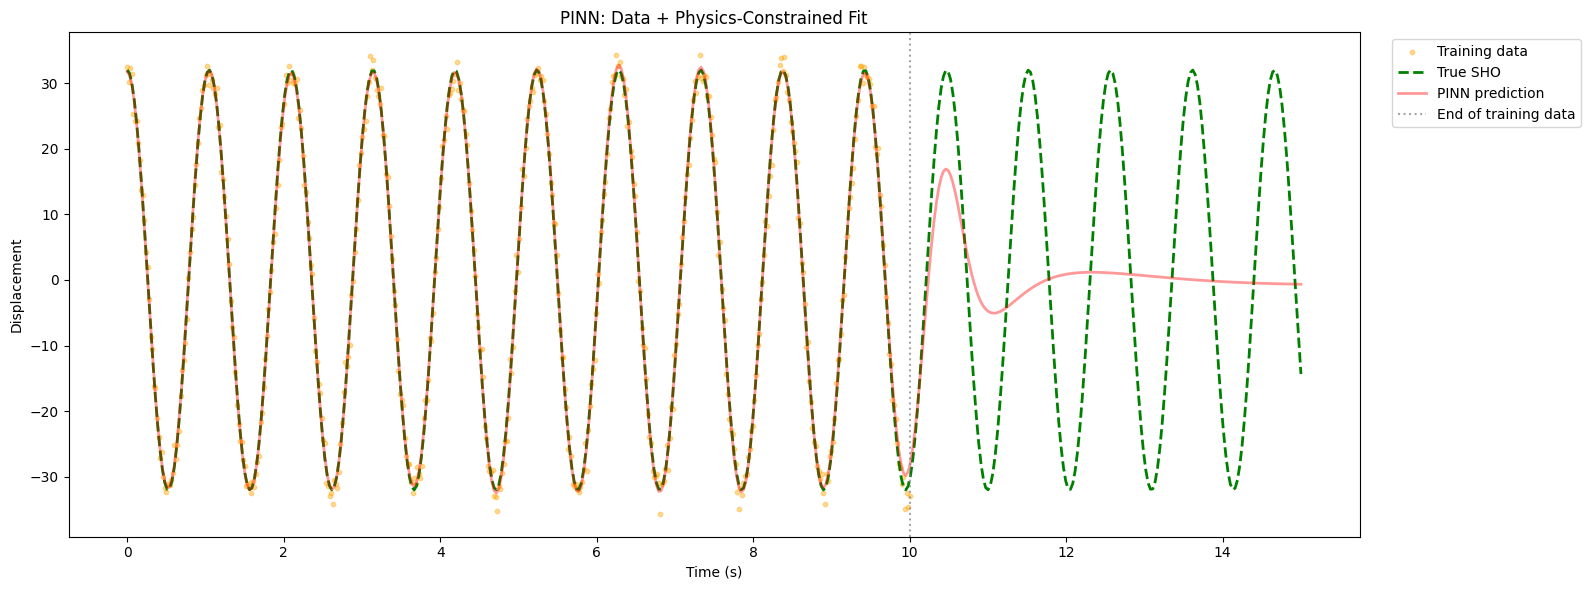

In [44]:
model.eval()
t_test = np.linspace(t_start, t_end + 5, 500)  # extends past training data!
t_test_tensor = torch.tensor(t_test, dtype=torch.float32).reshape(-1, 1)
t_test_norm = (t_test_tensor - t_mean) / t_std

with torch.no_grad():
    x_pred_norm = model(t_test_norm)
    x_pred = (x_pred_norm * x_std + x_mean).numpy().flatten()

x_true_test = A * np.cos(omega * t_test + phi)

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(t, x_noisy, s=10, color="orange", alpha=0.4, label="Training data")
ax.plot(t_test, x_true_test, color="green", linewidth=2, linestyle="--", label="True SHO")
ax.plot(t_test, x_pred, color="red", linewidth=2, alpha=0.4, label="PINN prediction")
ax.axvline(t_end, color="gray", linestyle=":", alpha=0.7, label="End of training data")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement")
ax.set_title("PINN: Data + Physics-Constrained Fit")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()